In [210]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


In [211]:
import pandas as pd
f_data = pd.read_excel(r"C:\Users\royr\Downloads\Sample_fraud_analytics_intern_v1.1.xlsx")

In [212]:
f_data.dtypes

timestamp         datetime64[us]
date              datetime64[us]
year                       int64
month                      int64
month_start       datetime64[us]
day                        int64
day_of_week                int64
hour                       int64
month_index                int64
vendor_id                    str
category                     str
region                       str
quantity                  object
unit_price                object
total_price               object
po_number                    str
invoice_number               str
dtype: object

In [213]:
f_data.shape

(18250, 17)

In [214]:
f_data.head()

,timestamp,date,year,month,month_start,day,day_of_week,hour,month_index,vendor_id,category,region,quantity,unit_price,total_price,po_number,invoice_number
0,2022-03-20 23:04:48,2022-03-20 23:04:48,2022,3,2022-03-01,20,6,23,9,V1024,anesthesia,EU,12,65.69,788.28,PO238345,INV806201
1,2022-07-28 16:33:49,2022-07-28 16:33:49,2022,7,2022-07-01,28,3,16,13,V1026,beds,APAC,1,2027.61,2027.61,PO407208,INV741207
2,2022-01-29 18:29:20,2022-01-29 18:29:20,2022,1,2022-01-01,29,5,18,7,V1003,gloves,APAC,578,0.061,35.26,PO790180,INV997615
3,2023-03-05 05:06:25,2023-03-05 05:06:25,2023,3,2023-03-01,5,6,5,21,V1005,anesthesia,APAC,11,45.02,495.22,PO788247,INV646044
4,2022-11-04 11:26:53,2022-11-04 11:26:53,2022,11,2022-11-01,4,4,11,17,V1034,syringes,EU,330,0.115,37.95,PO303013,INV817114


In [215]:
f_data.nunique()

timestamp         17420
date              17420
year                  4
month                12
month_start          48
day                  31
day_of_week           7
hour                 24
month_index          48
vendor_id            50
category              8
region                4
quantity           1103
unit_price         9410
total_price       14070
po_number         17244
invoice_number    17147
dtype: int64

In [216]:
# --- Missing values check ---
missing_values = f_data.isnull().sum()

print("Missing values per column:\n", missing_values)

Missing values per column:
 timestamp         0
date              0
year              0
month             0
month_start       0
day               0
day_of_week       0
hour              0
month_index       0
vendor_id         0
category          0
region            0
quantity          0
unit_price        0
total_price       0
po_number         0
invoice_number    0
dtype: int64


In [217]:
# f_data['total_price'] = f_data['total_price'].fillna(f_data['quantity'] * f_data['unit_price'])
# f_data['unit_price'] = f_data['unit_price'].fillna(f_data['total_price'] / f_data['quantity'])
# f_data['quantity'] = f_data['quantity'].fillna(f_data['total_price'] / f_data['unit_price'])
# f_data = f_data.dropna(subset=['quantity','unit_price','total_price'], how='all')
# # Drop rows where at least 2 of the 3 key numeric fields are missing
# f_data = f_data.dropna(
#     subset=['quantity','unit_price','total_price'],
#     thresh=2  # requires at least 2 non-missing values to keep the row
# )

# print("Remaining rows:", f_data.shape[0])


In [218]:
missing_values = f_data.isnull().sum()

print("Missing values per column:\n", missing_values)

Missing values per column:
 timestamp         0
date              0
year              0
month             0
month_start       0
day               0
day_of_week       0
hour              0
month_index       0
vendor_id         0
category          0
region            0
quantity          0
unit_price        0
total_price       0
po_number         0
invoice_number    0
dtype: int64


In [219]:
f_data['quantity']   = pd.to_numeric(f_data['quantity'], errors='coerce')
f_data['unit_price'] = pd.to_numeric(f_data['unit_price'], errors='coerce')
f_data['total_price'] = pd.to_numeric(f_data['total_price'], errors='coerce')

In [220]:
f_data.describe(include=[np.number])

,year,month,day,day_of_week,hour,month_index,quantity,unit_price,total_price
count,18250.000000,18250.000000,18250.000000,18250.000000,18250.000000,18250.000000,18232.000000,18233.000000,1.823600e+04
mean,2022.480658,6.501479,15.442356,2.994630,11.420000,18.406356,397.059401,957.153716,2.303475e+05
std,0.999470,3.407229,8.627310,2.006558,6.934985,11.138639,2427.577033,8721.526267,1.881846e+07
min,2021.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00
25%,2022.000000,4.000000,8.000000,1.000000,5.000000,9.000000,3.000000,0.250000,9.254250e+01
50%,2022.000000,6.000000,15.000000,3.000000,11.000000,18.000000,48.000000,46.510000,5.144800e+02
75%,2023.000000,9.000000,23.000000,5.000000,18.000000,28.000000,306.000000,727.410000,1.594477e+03
max,2024.000000,12.000000,31.000000,6.000000,23.000000,47.000000,76783.000000,470083.990000,2.500000e+09


In [221]:
vendor_counts = f_data['vendor_id'].value_counts(dropna=False)
region_counts = f_data['region'].value_counts(dropna=False)
category_counts = f_data['category'].value_counts(dropna=False)

print("Vendor frequency counts:")
print(vendor_counts)

print("\nRegion frequency counts:")
print(region_counts)

print("\nCategory frequency counts:")
print(category_counts)
region_counts = f_data['region'].value_counts(dropna=False)
category_counts = f_data['category'].value_counts(dropna=False)

print("Vendor frequency counts:")
print(vendor_counts)

print("\nRegion frequency counts:")
print(region_counts)

print("\nCategory frequency counts:")
print(category_counts)

Vendor frequency counts:
vendor_id
V1010    459
V1044    456
V1009    443
V1030    440
V1026    435
V1016    435
V1008    429
V1020    426
V1004    425
V1015    423
V1036    421
V1001    420
V1005    418
V1040    413
V1037    412
V1038    412
V1002    412
V1025    411
V1028    411
V1035    409
V1042    405
V1031    403
V1041    402
V1022    401
V1012    400
V1003    398
V1021    395
V1019    395
V1043    395
V1007    394
V1033    393
V1024    390
V1018    390
V1014    386
V1027    310
V1032    284
V1000    283
V1023    273
V1034    268
V1049    267
V1045    265
V1029    262
V1047    260
V1039    256
V1017    253
V1006    253
V1048    247
V1011    242
V1013    240
V1046    230
Name: count, dtype: int64

Region frequency counts:
region
UCAN     6612
APAC     4690
EU       3834
LATAM    3114
Name: count, dtype: int64

Category frequency counts:
category
anesthesia      3016
syringes        2966
beds            2544
gloves          2270
monitors        2245
IV_sets         1918
oxygen_tank

In [222]:
# vendor_counts = f_data['vendor_id'].value_counts()
# f_data['vendor_id_encoded'] = f_data['vendor_id'].map(vendor_counts)

# f_data = pd.get_dummies(f_data, columns=['category'], drop_first=True)

# f_data = pd.get_dummies(f_data, columns=['region'], drop_first=True)

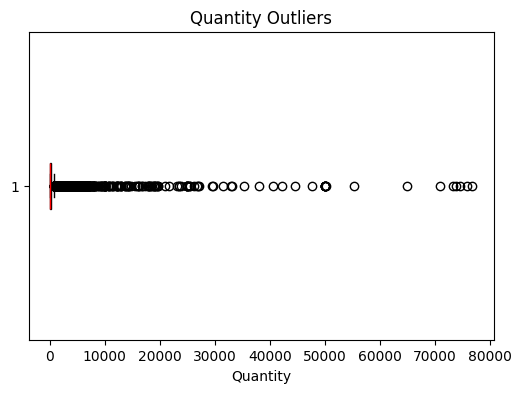

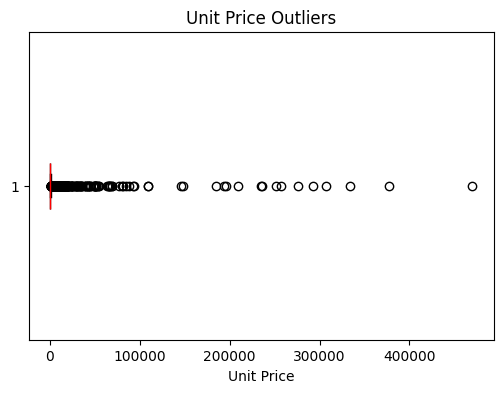

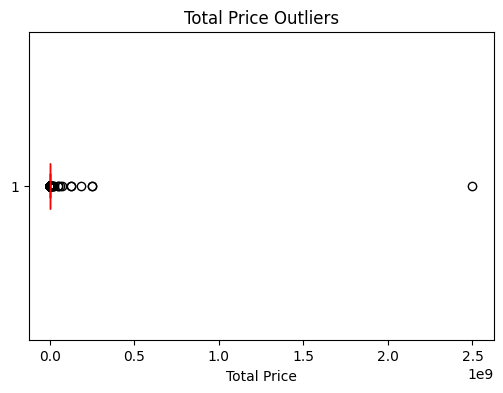

In [223]:
# Boxplot for Quantity
plt.figure(figsize=(6,4))
plt.boxplot(f_data['quantity'].dropna(), vert=False, patch_artist=True,
            boxprops=dict(facecolor='lightblue', color='black'),
            medianprops=dict(color='red'))
plt.title("Quantity Outliers")
plt.xlabel("Quantity")
plt.show()


# Boxplot for Unit Price
plt.figure(figsize=(6,4))
plt.boxplot(f_data['unit_price'].dropna(), vert=False, patch_artist=True,
            boxprops=dict(facecolor='lightgreen', color='black'),
            medianprops=dict(color='red'))
plt.title("Unit Price Outliers")
plt.xlabel("Unit Price")
plt.show()


# Boxplot for Total Price
plt.figure(figsize=(6,4))
plt.boxplot(f_data['total_price'].dropna(), vert=False, patch_artist=True,
            boxprops=dict(facecolor='lightyellow', color='black'),
            medianprops=dict(color='red'))
plt.title("Total Price Outliers")
plt.xlabel("Total Price")
plt.show()


In [224]:

f_data['total'] = f_data['quantity'] * f_data['unit_price']


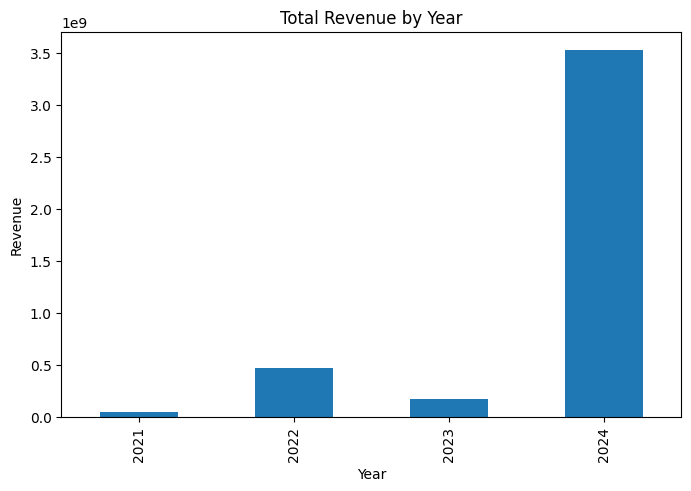

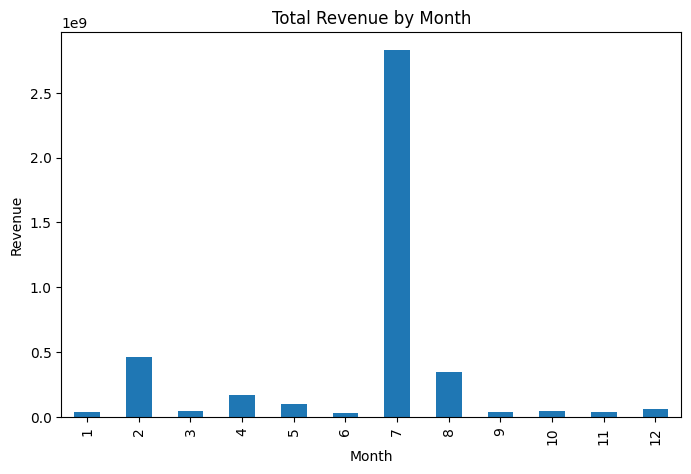

In [225]:
f_data.groupby('year')['total'].sum().plot(kind='bar', figsize=(8,5))
plt.title("Total Revenue by Year")
plt.xlabel("Year")
plt.ylabel("Revenue")
plt.show()

f_data.groupby('month')['total'].sum().plot(kind='bar', figsize=(8,5))
plt.title("Total Revenue by Month")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()


In [226]:

# Select only numeric columns
numeric_cols = f_data.select_dtypes(include=['float64','int64']).columns

# Compute stats
stats = pd.DataFrame({
    'std_dev': f_data[numeric_cols].std(),
    'skewness': f_data[numeric_cols].skew(),
    'kurtosis': f_data[numeric_cols].kurt()
})

print(stats)


                  std_dev    skewness      kurtosis
year         9.994703e-01    0.017164     -1.060911
month        3.407229e+00    0.006941     -1.181649
day          8.627310e+00    0.004498     -1.169222
day_of_week  2.006558e+00    0.009318     -1.259730
hour         6.934985e+00    0.016181     -1.210292
month_index  1.113864e+01    0.073365     -1.090926
quantity     2.427577e+03   18.740819    447.857875
unit_price   8.721526e+03   30.982664   1178.061281
total_price  1.881846e+07  128.905511  17081.704271
total        1.882155e+07  128.884301  17076.083635


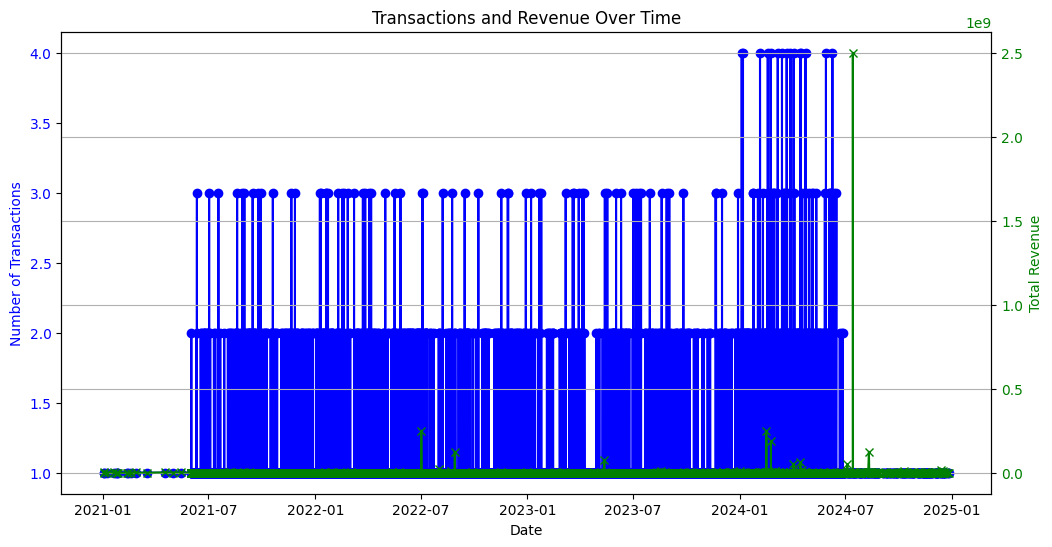

In [227]:
# Aggregate by date
daily_counts = f_data.groupby('date').size()
daily_revenue = f_data.groupby('date')['total'].sum()

fig, ax1 = plt.subplots(figsize=(12,6))

# Plot transaction counts
ax1.plot(daily_counts.index, daily_counts.values, color='blue', marker='o', label='Transactions')
ax1.set_xlabel("Date")
ax1.set_ylabel("Number of Transactions", color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Plot revenue on secondary axis
ax2 = ax1.twinx()
ax2.plot(daily_revenue.index, daily_revenue.values, color='green', marker='x', label='Revenue')
ax2.set_ylabel("Total Revenue", color='green')
ax2.tick_params(axis='y', labelcolor='green')

plt.title("Transactions and Revenue Over Time")
plt.grid(True)
plt.show()


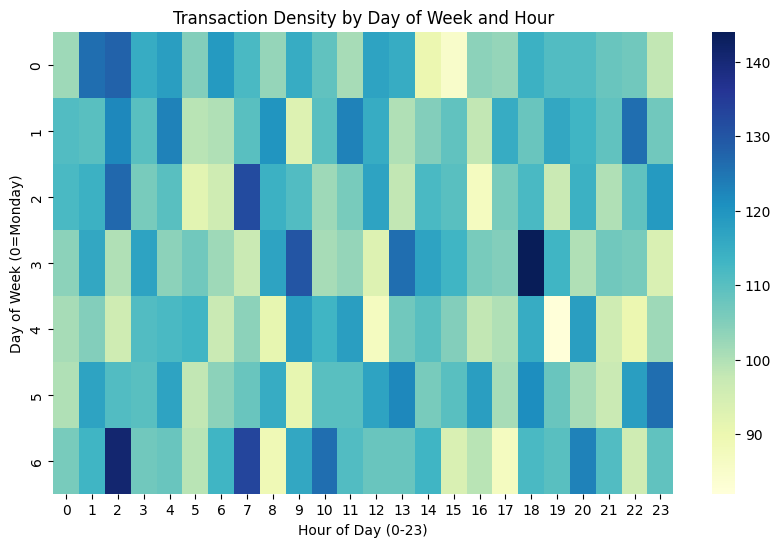

In [228]:
import seaborn as sns
import pandas as pd

# Create pivot table: counts by day_of_week and hour
heatmap_data = f_data.groupby(['day_of_week','hour']).size().unstack(fill_value=0)

plt.figure(figsize=(10,6))
sns.heatmap(heatmap_data, cmap="YlGnBu", annot=False, cbar=True)
plt.title("Transaction Density by Day of Week and Hour")
plt.xlabel("Hour of Day (0-23)")
plt.ylabel("Day of Week (0=Monday)")
plt.show()


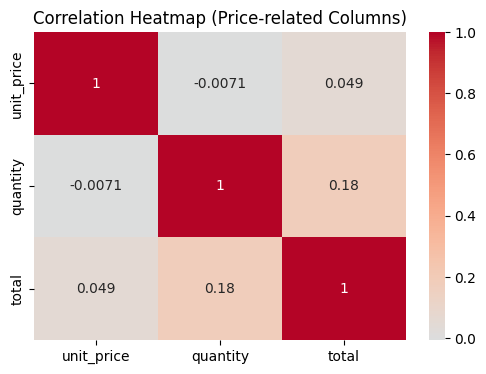

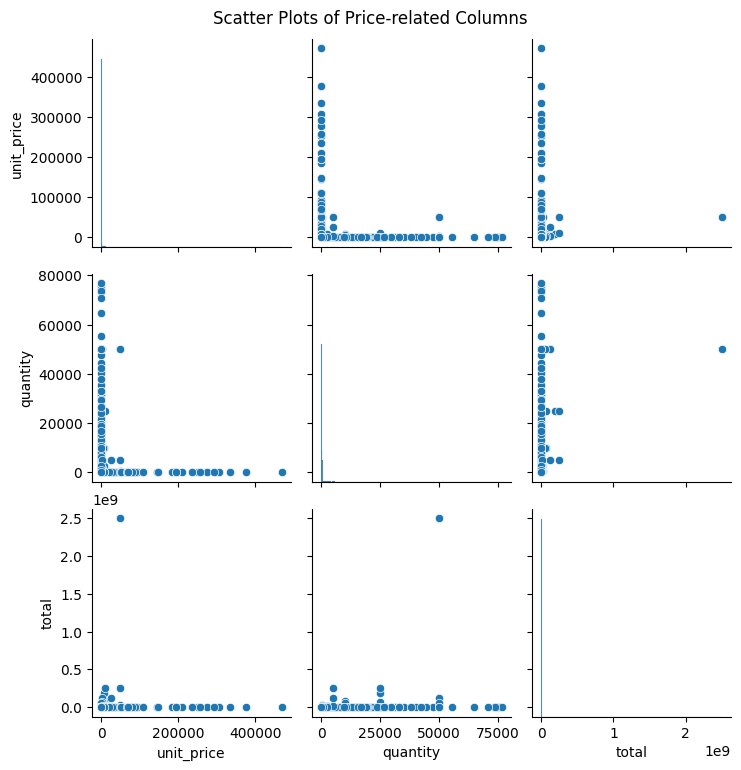

In [229]:

# --- Step 1: Make sure total exists ---
if 'total' not in f_data.columns:
    f_data['total'] = f_data['quantity'] * f_data['unit_price']

# --- Step 2: Select price-related columns ---
price_cols = ['unit_price', 'quantity', 'total']
price_data = f_data[price_cols]

# --- Step 3: Correlation matrix ---
corr_matrix = price_data.corr()

plt.figure(figsize=(6,4))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap (Price-related Columns)")
plt.show()

# --- Step 4: Scatter plots for pairwise relationships ---
sns.pairplot(price_data, diag_kind='hist')
plt.suptitle("Scatter Plots of Price-related Columns", y=1.02)
plt.show()



In [230]:

# Hour cyclical encoding (0–23)
f_data['hour_sin'] = np.sin(2 * np.pi * f_data['hour'] / 24)
f_data['hour_cos'] = np.cos(2 * np.pi * f_data['hour'] / 24)

# Day of week cyclical encoding (0–6)
f_data['dow_sin'] = np.sin(2 * np.pi * f_data['day_of_week'] / 7)
f_data['dow_cos'] = np.cos(2 * np.pi * f_data['day_of_week'] / 7)

# Check results
print(f_data[['hour','hour_sin','hour_cos','day_of_week','dow_sin','dow_cos']].head())


   hour  hour_sin      hour_cos  day_of_week   dow_sin   dow_cos
0    23 -0.258819  9.659258e-01            6 -0.781831  0.623490
1    16 -0.866025 -5.000000e-01            3  0.433884 -0.900969
2    18 -1.000000 -1.836970e-16            5 -0.974928 -0.222521
3     5  0.965926  2.588190e-01            6 -0.781831  0.623490
4    11  0.258819 -9.659258e-01            4 -0.433884 -0.900969


In [231]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(f_data[['quantity','unit_price','total_price','hour_sin','hour_cos','dow_sin','dow_cos']])


In [232]:
# # One-hot encode region
# region_dummies = pd.get_dummies(f_data['region'], prefix='region', drop_first=False)
# f_data = pd.concat([f_data, region_dummies], axis=1)

# # One-hot encode category
# category_dummies = pd.get_dummies(f_data['category'], prefix='category', drop_first=False)
# f_data = pd.concat([f_data, category_dummies], axis=1)

# # Frequency encode vendor_id
# vendor_freq = f_data['vendor_id'].map(vendor_counts)
# f_data['vendor_id_freq'] = vendor_freq

# # Display the new columns
# print("Region columns added:")
# print(region_dummies.columns.tolist())
# print("\nCategory columns added:")
# print(category_dummies.columns.tolist())
# print("\nVendor frequency encoding sample:")
# print(f_data[['vendor_id', 'vendor_id_freq']].head(10))
# print("\nDataFrame shape:", f_data.shape)

In [233]:
# Convert all boolean columns in f_data (and any standalone dummy DataFrames) to 0/1 binary
bool_cols = f_data.select_dtypes(include='bool').columns
f_data[bool_cols] = f_data[bool_cols].astype(int)

if 'region_dummies' in globals():
    region_dummies = region_dummies.astype(int)

if 'category_dummies' in globals():
    category_dummies = category_dummies.astype(int)

if 'df' in globals() and df.select_dtypes(include='bool').any().any():
    df[df.select_dtypes(include='bool').columns] = df.select_dtypes(include='bool').astype(int)

print("Converted boolean columns to integers:", list(bool_cols))

Converted boolean columns to integers: []


In [234]:
# Check if vendor_id, year, month, day, hour are same
# Then count those with different invoice_number or po_number

vendor_time_cols = ['vendor_id', 'year', 'month', 'day', 'hour']

# Group by vendor_time_cols and find duplicates
duplicates = f_data.groupby(vendor_time_cols).filter(lambda x: len(x) > 1)

# Among duplicates, find those with different invoice_number or po_number
different_invoices_or_pos = duplicates[
    (duplicates.groupby(vendor_time_cols)['invoice_number'].transform('nunique') > 1) |
    (duplicates.groupby(vendor_time_cols)['po_number'].transform('nunique') > 1)
]

# Count the groups with different invoices or POs
count_different = different_invoices_or_pos.groupby(vendor_time_cols).size().reset_index(name='count')

print("Groups with same vendor_id, year, month, day, hour but different invoice_number or po_number:")
print(count_different)
print(f"\nTotal groups with differences: {len(count_different)}")

Groups with same vendor_id, year, month, day, hour but different invoice_number or po_number:
    vendor_id  year  month  day  hour  count
0       V1000  2021     11    3    19      2
1       V1001  2021      9   22     1      2
2       V1001  2022      1   18     2      2
3       V1001  2022     10    7     9      2
4       V1001  2022     10    8    23      2
..        ...   ...    ...  ...   ...    ...
131     V1045  2023     12   13     0      2
132     V1046  2022      6   11     5      2
133     V1046  2023     12   25     6      2
134     V1046  2024      1    1    12      2
135     V1047  2022      3    4     8      2

[136 rows x 6 columns]

Total groups with differences: 136


In [235]:
# Round calculated and stated totals to 2 decimal places, then flag mismatches

expected_total = (f_data['quantity'] * f_data['unit_price']).round(2)
stated_total = f_data['total_price'].round(2)

valid_mask = f_data[['quantity', 'unit_price', 'total_price']].notna().all(axis=1)
disparity = (expected_total - stated_total).abs()

f_data['price_mismatch_flag'] = False
f_data.loc[valid_mask, 'price_mismatch_flag'] = (disparity.loc[valid_mask] > 0.02)

mismatch_rows = f_data.loc[f_data['price_mismatch_flag'], ['quantity', 'unit_price', 'total_price', 'price_mismatch_flag']]

print(f"Rows with mismatched totals: {mismatch_rows.shape[0]}")
mismatch_rows.head()

Rows with mismatched totals: 54


,quantity,unit_price,total_price,price_mismatch_flag
200,32.0,0.00,252218.56,True
255,0.0,0.00,465.70,True
8308,0.0,0.00,385.74,True
8340,0.0,0.00,179.36,True
17753,697.0,0.16,2113.66,True


In [236]:
key_cols = ['invoice_number', 'po_number', 'timestamp']
amount_cols = ['quantity', 'unit_price', 'total_price', 'total']

amount_variation = f_data.groupby(key_cols)[amount_cols].nunique()
mismatch_groups = amount_variation[(amount_variation > 1).any(axis=1)]

f_data['same_invoice_po_timestamp_diff_amount_flag'] = (
    f_data.set_index(key_cols).index.isin(mismatch_groups.index)
)

print("Rows flagged:", f_data['same_invoice_po_timestamp_diff_amount_flag'].sum())
f_data.loc[
    f_data['same_invoice_po_timestamp_diff_amount_flag'],
    key_cols + amount_cols
].head(10)

Rows flagged: 6


,invoice_number,po_number,timestamp,quantity,unit_price,total_price,total
199,INV678084,PO811407,2021-08-16 19:14:57,0.0,0.00,0.00,0.00
200,INV781696,PO508392,2021-09-09 10:51:25,32.0,0.00,252218.56,0.00
255,INV547541,PO509531,2022-04-08 02:43:05,0.0,0.00,465.70,0.00
17203,INV678084,PO811407,2021-08-16 19:14:57,308.0,0.17,52.36,52.36
17204,INV781696,PO508392,2021-09-09 10:51:25,32.0,7881.83,252218.56,252218.56
17259,INV547541,PO509531,2022-04-08 02:43:05,2.0,232.85,465.70,465.70


In [237]:
# # Flag same PO repeated with different invoices at the same timestamp
# f_data['same_po_timestamp_diff_invoice_flag'] = (
#     f_data.groupby(['timestamp', 'po_number'])['invoice_number'].transform('nunique') > 1
# )

# print("Rows flagged:", f_data['same_po_timestamp_diff_invoice_flag'].sum())
# # show sample flagged groups
# f_data.loc[f_data['same_po_timestamp_diff_invoice_flag'], ['timestamp', 'po_number', 'invoice_number']].drop_duplicates().head(20)

In [238]:
# flag rows where computed total differs from stated total_price
f_data['total_vs_total_price_diff'] = (f_data['total'] - f_data['total_price']).abs()
f_data['total_vs_total_price_flag'] = f_data['total_vs_total_price_diff'] > 0.01

print("Rows with total mismatch:", f_data['total_vs_total_price_flag'].sum())
f_data.loc[
    f_data['total_vs_total_price_flag'],
    ['quantity', 'unit_price', 'total', 'total_price', 'total_vs_total_price_diff']
].head()

Rows with total mismatch: 54


,quantity,unit_price,total,total_price,total_vs_total_price_diff
200,32.0,0.00,0.00,252218.56,252218.56
255,0.0,0.00,0.00,465.70,465.70
8308,0.0,0.00,0.00,385.74,385.74
8340,0.0,0.00,0.00,179.36,179.36
17753,697.0,0.16,111.52,2113.66,2002.14


In [239]:
# Count how many times each vendor has purchased each item
item_purchase_count_vendor = (
    f_data.groupby(['vendor_id', 'category'])
    .size()
    .reset_index(name='item_purchase_count_vendor')
)

# Merge back into the main DataFrame
f_data = f_data.merge(item_purchase_count_vendor, on=['vendor_id', 'category'], how='left')


In [240]:
# Calculate historical mean and std for each vendor-item pair
f_data['avg_quantity_vendor_item'] = (
    f_data.groupby(['vendor_id', 'category'])['quantity']
    .transform('mean')
)

f_data['std_quantity_vendor_item'] = (
    f_data.groupby(['vendor_id', 'category'])['quantity']
    .transform('std')
)


In [241]:
# Z-score: how far current quantity deviates from historical mean
f_data['item_quantity_zscore'] = (
    (f_data['quantity'] - f_data['avg_quantity_vendor_item']) /
    f_data['std_quantity_vendor_item']
)


In [242]:
# Flag if z-score is unusually high (e.g., > 3 standard deviations)
f_data['is_excess_item_purchase'] = f_data['item_quantity_zscore'] > 3


In [243]:
print("Rows flagged as excess purchases:", f_data['is_excess_item_purchase'].sum())
# Handle cases where std is NaN or 0
f_data['std_quantity_vendor_item'] = f_data['std_quantity_vendor_item'].replace(0, 1).fillna(1)

# Compute z-score safely
f_data['item_quantity_zscore'] = (
    (f_data['quantity'] - f_data['avg_quantity_vendor_item']) /
    f_data['std_quantity_vendor_item']
)



Rows flagged as excess purchases: 104


In [244]:
# Vendor's most frequent region (mode)
vendor_region_mode = (
    f_data.groupby('vendor_id')['region']
    .agg(lambda x: x.mode()[0] if not x.mode().empty else None)
    .reset_index(name='vendor_region_mode')
)

# Merge back
f_data = f_data.merge(vendor_region_mode, on='vendor_id', how='left')

# Flag region change
f_data['region_changed'] = f_data['region'] != f_data['vendor_region_mode']


In [245]:
# Vendor's most common transaction hour
f_data['transaction_hour'] = f_data['timestamp'].dt.hour

vendor_hour_mode = (
    f_data.groupby('vendor_id')['transaction_hour']
    .agg(lambda x: x.mode()[0] if not x.mode().empty else None)
    .reset_index(name='vendor_hour_mode')
)

f_data = f_data.merge(vendor_hour_mode, on='vendor_id', how='left')

# Flag unusual hours
f_data['is_outside_usual_hours'] = f_data['transaction_hour'] != f_data['vendor_hour_mode']


In [246]:
# Sort by vendor and timestamp
f_data = f_data.sort_values(['vendor_id', 'timestamp'])

# Time difference between consecutive transactions
f_data['inter_transaction_time'] = f_data.groupby('vendor_id')['timestamp'].diff().dt.total_seconds()

# Flag burst activity (e.g., < 300 seconds = 5 minutes)
f_data['is_burst_activity'] = f_data['inter_transaction_time'] < 300


In [247]:
# Vendor historical mean and std of amounts
f_data['vendor_amount_mean'] = f_data.groupby('vendor_id')['total_price'].transform('mean')
f_data['vendor_amount_std'] = f_data.groupby('vendor_id')['total_price'].transform('std').replace(0, 1).fillna(1)

# Z-score for transaction amount
f_data['amount_zscore'] = (f_data['total_price'] - f_data['vendor_amount_mean']) / f_data['vendor_amount_std']

# Flag outliers (e.g., > 3 std deviations)
f_data['is_amount_outlier'] = f_data['amount_zscore'].abs() > 3


In [248]:
# Step 1: Create a proper date column from year, month, day
f_data['date'] = pd.to_datetime(f_data[['year','month','day']])

# Step 2: Count transactions per vendor per day
daily_counts = (
    f_data.groupby(['vendor_id','date'])
    .size()
    .reset_index(name='daily_txn_count')
)

# Step 3: Compute rolling 7-day average per vendor
daily_counts['rolling_txn_count'] = (
    daily_counts.groupby('vendor_id')['daily_txn_count']
    .transform(lambda x: x.rolling(7, min_periods=1).mean())
)

# Step 4: Merge back into main DataFrame
f_data = f_data.merge(daily_counts, on=['vendor_id','date'], how='left')

# Step 5: Compare rolling count to historical mean
f_data['vendor_txn_mean'] = f_data.groupby('vendor_id')['daily_txn_count'].transform('mean')
f_data['frequency_change_ratio'] = f_data['rolling_txn_count'] / f_data['vendor_txn_mean']

# Flag spikes/drops
f_data['is_frequency_spike_drop'] = (f_data['frequency_change_ratio'] > 2) | (f_data['frequency_change_ratio'] < 0.5)


In [249]:
# Step 1: Count transactions per vendor per month
vendor_monthly_activity = (
    f_data.groupby(['vendor_id','year','month'])
    .size()
    .reset_index(name='txn_count_month')
)

# Step 2: Compute vendor’s average monthly activity
vendor_monthly_activity['avg_txn_per_month_vendor'] = (
    vendor_monthly_activity.groupby('vendor_id')['txn_count_month']
    .transform('mean')
)

# Step 3: Merge back into main DataFrame
# Use unique column names to avoid clashes
f_data = f_data.merge(
    vendor_monthly_activity[['vendor_id','year','month','txn_count_month','avg_txn_per_month_vendor']],
    on=['vendor_id','year','month'],
    how='left'
)

# Step 4: Flag deviations from seasonal norms
f_data['deviation_from_avg_vendor_month'] = f_data['txn_count_month'] - f_data['avg_txn_per_month_vendor']
f_data['flag_seasonal_anomaly_vendor'] = (
    f_data['deviation_from_avg_vendor_month'].abs() > f_data['avg_txn_per_month_vendor'] * 0.5
)



In [250]:
# Step A: Category quantity z-score per vendor
f_data['category_quantity_mean'] = f_data.groupby(['vendor_id','category'])['quantity'].transform('mean')
f_data['category_quantity_std'] = f_data.groupby(['vendor_id','category'])['quantity'].transform('std')

# Avoid division by zero
f_data['category_quantity_zscore'] = (
    (f_data['quantity'] - f_data['category_quantity_mean']) / f_data['category_quantity_std'].replace(0,1)
)

# Step B: Excess category purchase flag
f_data['is_excess_category_purchase'] = f_data['category_quantity_zscore'].abs() > 3  # threshold can be tuned

# Step C: New category for vendor flag
# Mark first occurrence of a category for each vendor
f_data['is_new_category_for_vendor'] = (
    f_data.groupby('vendor_id')['category'].transform(lambda x: ~x.duplicated())
)


In [251]:
# Step 1: Collect all engineered features into a single matrix
feature_cols = [
    # Item/Category
    'category_quantity_zscore','is_excess_category_purchase','is_new_category_for_vendor',

    # Vendor Geography
    'region_changed',

    # Vendor Temporal
    'is_outside_usual_hours','is_burst_activity',

    # Vendor Amount
    'amount_zscore','is_amount_outlier',

    # Vendor Frequency & Seasonality
    'frequency_change_ratio','is_frequency_spike_drop',
    'deviation_from_avg_vendor_month','flag_seasonal_anomaly_vendor'
]

# Step 2: Create the feature matrix (X)
X = f_data[feature_cols].copy()

# Step 3: Handle missing values
X = X.fillna(0)

# Step 4: Ensure all boolean flags are numeric (0/1)
X = X.astype(float)


In [252]:
from sklearn.ensemble import IsolationForest


In [253]:
from sklearn.preprocessing import StandardScaler

# Step 1: Identify continuous features (to scale)
continuous_cols = [
    'category_quantity_zscore',
    'amount_zscore',
    'frequency_change_ratio',
    'deviation_from_avg_vendor_month'
]

# Step 2: Scale them
scaler = StandardScaler()
X[continuous_cols] = scaler.fit_transform(X[continuous_cols])


In [277]:
from sklearn.ensemble import IsolationForest

# Step 1: Initialize the model
iso = IsolationForest(
    contamination='auto',   # expected proportion of anomalies (tune this!)
    random_state=42
)

# Step 2: Fit the model on your feature matrix
iso.fit(X)

# Step 3: Generate anomaly predictions
f_data['anomaly_score'] = iso.predict(X)   # -1 = anomaly, 1 = normal

# Step 4: Create a binary anomaly flag
f_data['is_anomaly'] = f_data['anomaly_score'] == -1


In [278]:
# Step 1: Check anomaly rate
anomaly_rate = f_data['is_anomaly'].mean()
print("Percentage of anomalies flagged:", anomaly_rate * 100)

# Step 2: Inspect a few anomalies
anomalies = f_data[f_data['is_anomaly'] == True]
print(anomalies[[
    'vendor_id','year','month','amount_zscore',
    'category_quantity_zscore','frequency_change_ratio',
    'deviation_from_avg_vendor_month'
]].head(10))

# Step 3: Compare anomalies vs normal
normals = f_data[f_data['is_anomaly'] == False]
print("Average values for anomalies:")
print(anomalies[[
    'amount_zscore','category_quantity_zscore',
    'frequency_change_ratio','deviation_from_avg_vendor_month'
]].mean())

print("Average values for normal transactions:")
print(normals[[
    'amount_zscore','category_quantity_zscore',
    'frequency_change_ratio','deviation_from_avg_vendor_month'
]].mean())


Percentage of anomalies flagged: 13.315068493150687
   vendor_id  year  month  amount_zscore  category_quantity_zscore  \
0      V1000  2021      1      -0.143091                -10.292098   
10     V1000  2021      7      -0.165104                 -0.554629   
19     V1000  2021      7      -0.165107                  0.448007   
25     V1000  2021      8      -0.165101                  0.431013   
33     V1000  2021      9      -0.165098                  0.125124   
34     V1000  2021      9      -0.165098                  0.125124   
39     V1000  2021     10      -0.164908                 -0.506881   
40     V1000  2021     11      -0.165119                       NaN   
41     V1000  2021     11      -0.165119                 -0.577159   
49     V1000  2021     11      -0.165100                  0.210093   

    frequency_change_ratio  deviation_from_avg_vendor_month  
0                  0.68523                           -6.075  
10                 0.97890                           

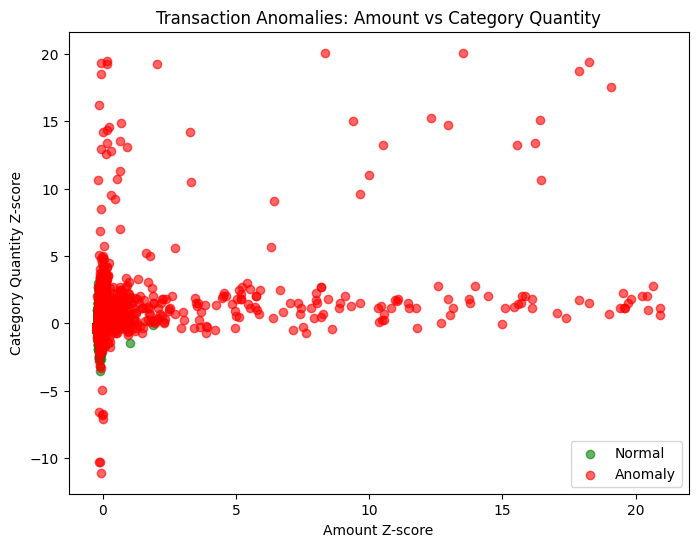

In [270]:
import matplotlib.pyplot as plt

# Scatter plot: Amount vs Category Quantity
plt.figure(figsize=(8,6))
plt.scatter(
    f_data.loc[f_data['is_anomaly']==False, 'amount_zscore'],
    f_data.loc[f_data['is_anomaly']==False, 'category_quantity_zscore'],
    c='green', label='Normal', alpha=0.6
)
plt.scatter(
    f_data.loc[f_data['is_anomaly']==True, 'amount_zscore'],
    f_data.loc[f_data['is_anomaly']==True, 'category_quantity_zscore'],
    c='red', label='Anomaly', alpha=0.6
)


plt.xlabel('Amount Z-score')
plt.ylabel('Category Quantity Z-score')
plt.title('Transaction Anomalies: Amount vs Category Quantity')
plt.legend()
plt.show()


In [271]:

def categorize_z(z):
    if abs(z) < 2:
        return "Green"   # Normal
    elif abs(z) <= 3:
        return "Yellow"  # Borderline
    else:
        return "Red"     # Likely anomaly

# Apply to amount and category z-scores
f_data['amount_zone'] = f_data['amount_zscore'].apply(categorize_z)
f_data['category_zone'] = f_data['category_quantity_zscore'].apply(categorize_z)

# Distribution counts
print("Amount zones:")
print(f_data['amount_zone'].value_counts(normalize=True) * 100)

print("\nCategory zones:")
print(f_data['category_zone'].value_counts(normalize=True) * 100)

# Focus only on ML anomalies
ml_anomalies = f_data[f_data['is_anomaly'] == True]
print("\nML anomalies by amount zone:")
print(ml_anomalies['amount_zone'].value_counts(normalize=True) * 100)

print("\nML anomalies by category zone:")
print(ml_anomalies['category_zone'].value_counts(normalize=True) * 100)


Amount zones:
amount_zone
Green     99.063014
Red        0.821918
Yellow     0.115068
Name: proportion, dtype: float64

Category zones:
category_zone
Green     96.991781
Yellow     2.164384
Red        0.843836
Name: proportion, dtype: float64

ML anomalies by amount zone:
amount_zone
Green     93.539095
Red        5.596708
Yellow     0.864198
Name: proportion, dtype: float64

ML anomalies by category zone:
category_zone
Green     89.135802
Red        5.473251
Yellow     5.390947
Name: proportion, dtype: float64


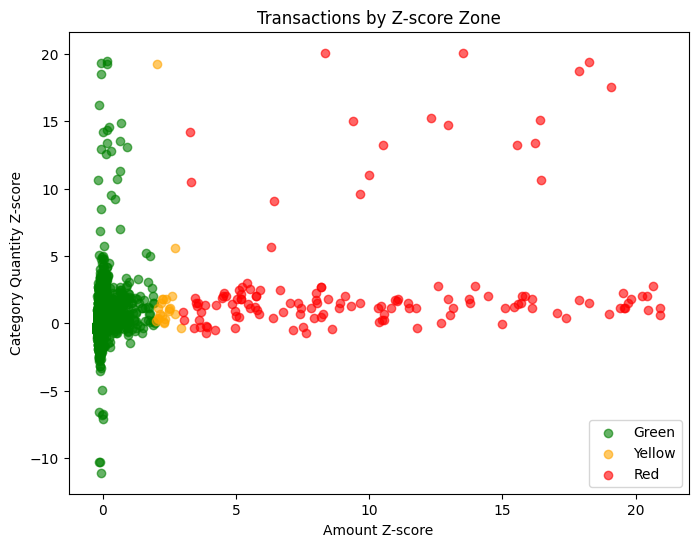

In [272]:


colors = {
    "Green": "green",
    "Yellow": "orange",
    "Red": "red"
}

plt.figure(figsize=(8,6))
for zone in ["Green","Yellow","Red"]:
    subset = f_data[f_data['amount_zone'] == zone]
    plt.scatter(
        subset['amount_zscore'],
        subset['category_quantity_zscore'],
        c=colors[zone],
        label=zone,
        alpha=0.6
    )

plt.xlabel('Amount Z-score')
plt.ylabel('Category Quantity Z-score')
plt.title('Transactions by Z-score Zone')
plt.legend()
plt.show()


In [276]:
from sklearn.svm import OneClassSVM

# Step 1: Train a One-Class SVM
# X is your feature matrix (numeric columns you want to use)
svm_model = OneClassSVM(
    kernel="rbf",        # radial basis function kernel (common choice)
    nu=0.04,             # proportion of anomalies expected (similar to contamination)
    gamma="scale"        # kernel coefficient
)
svm_model.fit(X)

# Step 2: Get anomaly predictions
# -1 = anomaly, +1 = normal
f_data['is_svm_anomaly'] = svm_model.predict(X) == -1

# Step 3: Inspect anomaly percentage
print("SVM anomalies %:", f_data['is_svm_anomaly'].mean() * 100)

# Step 4: Compare with Isolation Forest
print("Isolation Forest anomalies %:", f_data['is_anomaly'].mean() * 100)


SVM anomalies %: 4.021917808219178
Isolation Forest anomalies %: 4.0


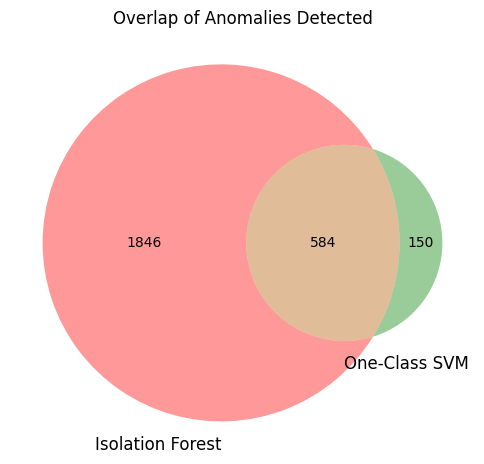

In [282]:
import matplotlib.pyplot as plt
from matplotlib_venn import venn2

# Count anomalies from both models
iso_anomalies = set(f_data[f_data['is_anomaly']].index)
svm_anomalies = set(f_data[f_data['is_svm_anomaly']].index)

# Intersection
both_anomalies = iso_anomalies & svm_anomalies

# Venn diagram
plt.figure(figsize=(6,6))
venn2(
    subsets = (
        len(iso_anomalies - svm_anomalies),   # Isolation Forest only
        len(svm_anomalies - iso_anomalies),   # SVM only
        len(both_anomalies)                   # Both models
    ),
    set_labels = ('Isolation Forest', 'One-Class SVM')
)
plt.title("Overlap of Anomalies Detected")
plt.show()


In [285]:
input_dim = X_scaled.shape[1]  # should be 7 in your case

class Autoencoder(nn.Module):
    def __init__(self, input_dim, encoding_dim=4):
        super(Autoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 16),   # input_dim must equal your feature count
            nn.ReLU(),
            nn.Linear(16, encoding_dim),
            nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.Linear(encoding_dim, 16),
            nn.ReLU(),
            nn.Linear(16, input_dim)    # output must also match input_dim
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

# Instantiate with correct input_dim
model = Autoencoder(input_dim=X_scaled.shape[1])



In [300]:
# Try a smaller encoding dimension
model = Autoencoder(input_dim=X_scaled.shape[1], encoding_dim=3)

# Train again, then compute errors
X_recon = model(X_tensor).detach().numpy()
mse = np.mean((X_scaled - X_recon)**2, axis=1)

# Use a lower threshold
threshold = np.percentile(mse, 90)  # instead of 95
f_data['is_autoencoder_anomaly'] = mse > threshold


In [301]:
# Get reconstructed outputs
with torch.no_grad():
    X_recon = model(X_tensor)

# Compute reconstruction error (MSE per row)
mse = torch.mean((X_tensor - X_recon) ** 2, dim=1).numpy()
f_data['reconstruction_error'] = mse


In [302]:
threshold = np.percentile(mse, 95)
f_data['is_autoencoder_anomaly'] = mse > threshold


In [303]:
print("Autoencoder anomalies %:", f_data['is_autoencoder_anomaly'].mean() * 100)

# See top anomalies
f_data.sort_values('reconstruction_error', ascending=False).head(10)


Autoencoder anomalies %: 0.0


,timestamp,date,year,month,month_start,day,day_of_week,hour,month_index,vendor_id,...,category_quantity_zscore,is_excess_category_purchase,is_new_category_for_vendor,anomaly_score,is_anomaly,amount_zone,category_zone,is_svm_anomaly,reconstruction_error,is_autoencoder_anomaly
18172,2023-09-21 13:59:39,2023-09-21,2023,9,2023-09-01,21,3,13,27,V1049,...,0.392052,False,False,1,False,Green,Green,False,2662.592285,False
18179,2023-10-04 22:09:57,2023-10-04,2023,10,2023-10-01,4,2,22,28,V1049,...,-0.504831,False,False,-1,True,Green,Green,False,417.959412,False
17992,2021-07-06 00:27:31,2021-07-06,2021,7,2021-07-01,6,1,0,1,V1049,...,0.377964,False,False,1,False,Green,Green,False,269.447357,False
18027,2021-12-21 22:26:02,2021-12-21,2021,12,2021-12-01,21,1,22,6,V1049,...,-0.152046,False,False,1,False,Green,Green,False,210.316696,False
17954,2024-03-06 14:09:15,2024-03-06,2024,3,2024-03-01,6,2,14,33,V1048,...,-0.607399,False,False,1,False,Green,Green,False,177.321442,False
17988,2021-06-21 16:54:17,2021-06-21,2021,6,2021-06-01,21,0,16,0,V1049,...,-0.372118,False,False,1,False,Green,Green,False,161.521942,False
18056,2022-04-21 09:20:22,2022-04-21,2022,4,2022-04-01,21,3,9,10,V1049,...,-0.262950,False,False,1,False,Green,Green,False,145.533157,False
17848,2023-01-22 23:59:59,2023-01-22,2023,1,2023-01-01,22,6,23,19,V1048,...,-0.419992,False,False,1,False,Green,Green,False,143.156403,False
17999,2021-08-08 10:51:20,2021-08-08,2021,8,2021-08-01,8,6,10,2,V1049,...,-1.136288,False,False,1,False,Green,Green,False,141.956192,False
18048,2022-03-25 23:02:05,2022-03-25,2022,3,2022-03-01,25,4,23,9,V1049,...,0.392052,False,False,1,False,Green,Green,False,137.389297,False
